In [ ]:
!pip install -q datasets scikit-learn pandas matplotlib seaborn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [ ]:
ds = load_dataset("zefang-liu/phishing-email-dataset")

print(ds)


DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'Email Text', 'Email Type'],
        num_rows: 18650
    })
})


In [ ]:
print(ds["train"].column_names)


['Unnamed: 0', 'Email Text', 'Email Type']


In [ ]:
print(ds["train"][0])


{'Unnamed: 0': 0, 'Email Text': 're : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson \'s observations on us use of \'s on \' but not \'d aughter \' as a vocative are very thought-provoking , but i am not sure that it is fair to attribute this to " sons " being " treated like senior relatives " . for one thing , we do n\'t normally use \' brother \' in this way any more than we do \'d aughter \' , and it is hard to imagine a natural class comprising senior relatives and \'s on \' but excluding \' brother \' . for another , there seem to me to be differences here . if i am not imagining a distinction that is not there , it seems to me that the senior relative terms are used in a wider variety of contexts , e . g . , calling out from a distance to get someone \'s attention , and hence at the beginning of an utterance , whereas \'s on \' seems more natural in utterances like \' yes , son \' , \' hand me that , son \' than in ones like \' son ! \' or \' son , help 

In [ ]:
df = ds["train"].to_pandas()

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())


Dataset shape: (18650, 3)

Columns:
Index(['Unnamed: 0', 'Email Text', 'Email Type'], dtype='object')

First 5 rows:


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [ ]:
print(df["Email Type"].value_counts())


Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64


In [ ]:
df = df.drop(columns=["Unnamed: 0"])

print(df.head())


                                          Email Text      Email Type
0  re : 6 . 1100 , disc : uniformitarianism , re ...      Safe Email
1  the other side of * galicismos * * galicismo *...      Safe Email
2  re : equistar deal tickets are you still avail...      Safe Email
3  \nHello I am your hot lil horny toy.\n    I am...  Phishing Email
4  software at incredibly low prices ( 86 % lower...  Phishing Email


In [ ]:
print(df.isnull().sum())


Email Text    16
Email Type     0
dtype: int64


In [ ]:
df = df.dropna(subset=["Email Text", "Email Type"])


In [ ]:
X = df["Email Text"]
y = df["Email Type"]


In [ ]:
print(y.value_counts())


Email Type
Safe Email        11322
Phishing Email     7312
Name: count, dtype: int64


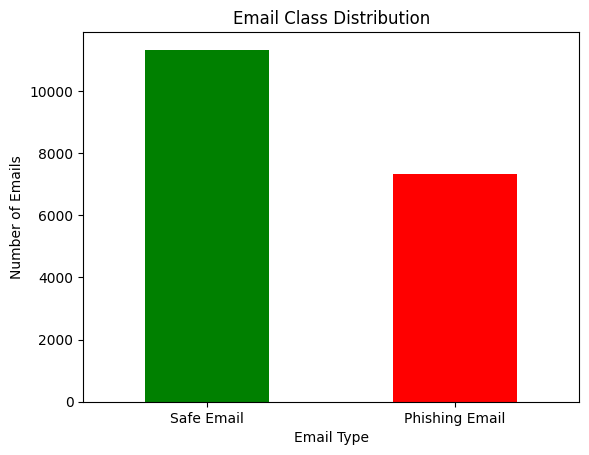

In [ ]:
import matplotlib.pyplot as plt

y.value_counts().plot(
    kind="bar",
    color=["green", "red"]
)

plt.title("Email Class Distribution")
plt.xlabel("Email Type")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training emails:", len(X_train))
print("Testing emails:", len(X_test))


Training emails: 14907
Testing emails: 3727


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)


Training shape: (14907, 649107)
Testing shape: (3727, 649107)


In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm.fit(X_train_tfidf, y_train)

print("Model training completed!")


Model training completed!


In [ ]:
y_pred = svm.predict(X_test_tfidf)

print(y_pred[:20])


['Safe Email' 'Safe Email' 'Safe Email' 'Safe Email' 'Phishing Email'
 'Phishing Email' 'Phishing Email' 'Safe Email' 'Phishing Email'
 'Safe Email' 'Safe Email' 'Safe Email' 'Phishing Email' 'Safe Email'
 'Phishing Email' 'Phishing Email' 'Phishing Email' 'Phishing Email'
 'Phishing Email' 'Safe Email']


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)


Accuracy: 0.9801448886503891
Accuracy (%): 98.01448886503891


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


                precision    recall  f1-score   support

Phishing Email       0.96      0.99      0.98      1462
    Safe Email       0.99      0.97      0.98      2265

      accuracy                           0.98      3727
     macro avg       0.98      0.98      0.98      3727
  weighted avg       0.98      0.98      0.98      3727



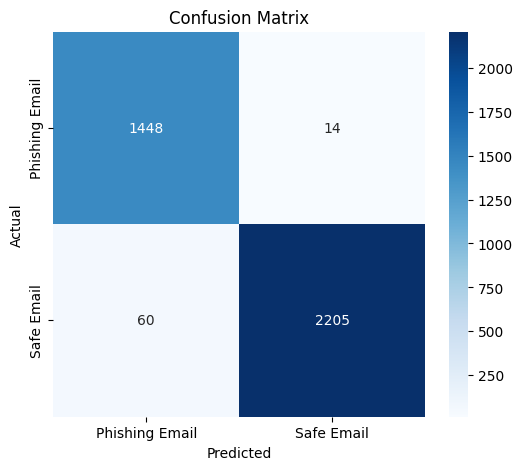

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Phishing Email", "Safe Email"],
    yticklabels=["Phishing Email", "Safe Email"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [ ]:
new_email = """
URGENT! Your account has been suspended.
Click here immediately to verify your password
and restore your account.
"""


In [ ]:
new_email_tfidf = tfidf.transform([new_email])


In [ ]:
prediction = svm.predict(new_email_tfidf)

print("Prediction:", prediction[0])


Prediction: Phishing Email


In [ ]:
new_email = """
Hi John,

Please send me the project report before tomorrow's
meeting. We can discuss the remaining tasks then.

Thanks.
"""


In [ ]:
prediction = svm.predict(tfidf.transform([new_email]))

print("Prediction:", prediction[0])


Prediction: Safe Email
